Importamos las Librerias Necesarias

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Conectamos a la DB y cargamos una pequeña tabla para validar correcta conexión

In [2]:
import pandas as pd
from sqlalchemy import create_engine

# Parámetros de conexión
user = "coniitic_registro"
password = "G3!+GUyN-1bXP+]x"
host = "coniiti.com"
database = "coniitic_registro"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}/{database}"
)

# Consulta (cambia el nombre si tu tabla no se llama regeventos)
query = "SELECT * FROM regeventos"

df = pd.read_sql(query, engine)

df.head()


,id,qr_Acceso,nombres,apellidos,email,telefono,tipo_documento,num_documento,genero,pais,ucatolica,rol,programa,profesion,nom_Evento,qr_validado,fecha_uso,fecha_registro
0,4,OXL3IHNL6KFN8KGPQE,yenny,hernandez,jphernandez@ucatolica.edu.co,3168232187,CC,1024486270,Femenino,Colombia,S,Administrativo,Facultad de Ingeniería,Adminsitradora financiera,Del reto a la solución: Innovar con Design Thi...,1,2025-10-01 15:05:30,2025-09-30 13:58:57
1,5,5RBN17AAE2OOL47485,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Workshop: Diseños de mezcla de concreto bajo l...,0,NaT,2025-09-30 18:15:53
2,6,R2SV7WXIAQ63Y1GIL3,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Conferencia : Arquitectura y diseño sostenible...,0,NaT,2025-09-30 18:31:52
3,7,P58X4OTXBNFUAQIJ54,Diego Fernando,Meléndez Suárez,dfmelendez@ucatolica.edu.co,3183530817,CC,91284150,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Ingeniería de Pavimentos,Ingeniero Civil,Conferencia: Proyectos comprometidos con la so...,0,NaT,2025-09-30 18:32:43
4,8,MK8DW21CHVHXTGBAS5,Oscar Raul,Pinto Celis,orpinto@ucatolica.edu.co,3125812914,CC,91500261,Masculino,Colombia,S,Profesor/Administrativo,Esp. en Gerencia de Obras,Ingeniero Civil,Conferencia: Premio Nacional de Ingeniería: Re...,1,2025-10-02 14:05:02,2025-09-30 18:32:53


creamos una grafica usando los campos de nombre_Evento para comparar inscritos vs asistentes y su tasa promedios

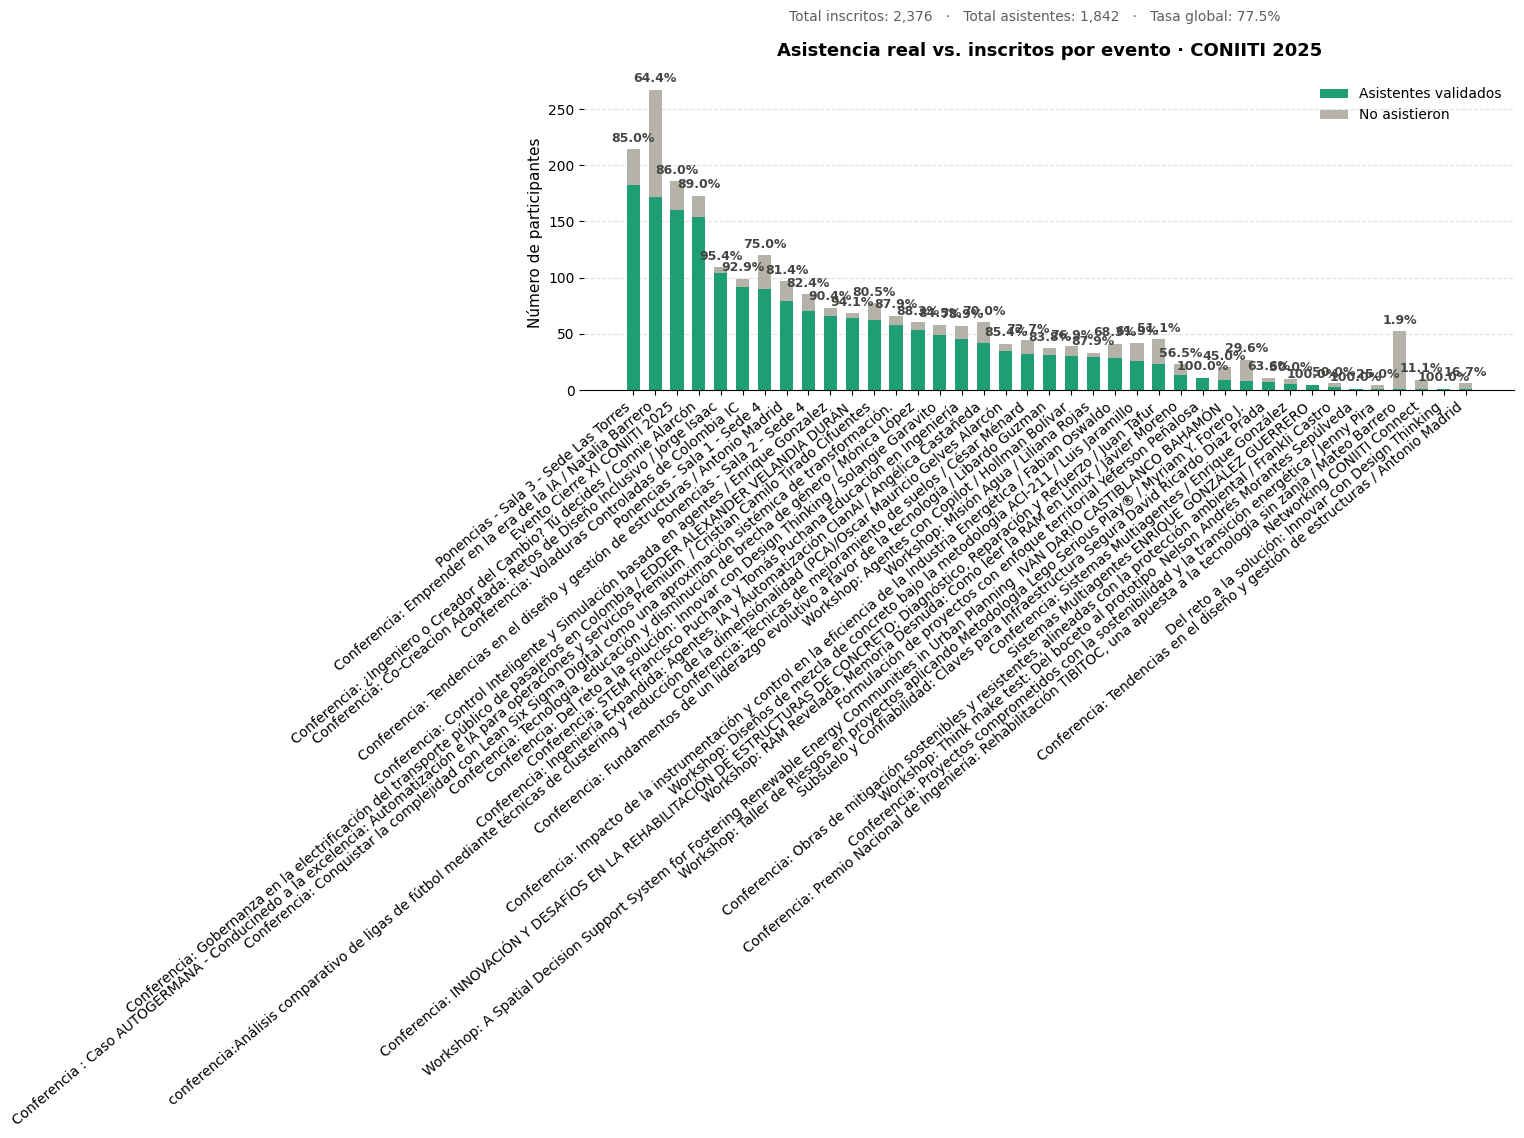

In [5]:

# ── datos ────────────────────────────────────────────────────────
# Asume que tienes estos dos Series indexadas por nombre de evento
# asistencia_evento  → qr_validado == 1  (ya lo tienes)
# inscritos_evento   → total de registros por evento

inscritos_evento = df.groupby("nom_Evento")["id"].count()
asistencia_evento = df[df["qr_validado"] == 1].groupby("nom_Evento")["id"].count()

# Ordenar de mayor a menor asistencia
orden = asistencia_evento.sort_values(ascending=False).index
asistentes = asistencia_evento.reindex(orden).fillna(0)
inscritos   = inscritos_evento.reindex(orden).fillna(0)
no_asistieron = inscritos - asistentes
tasas = (asistentes / inscritos * 100).round(1)

# ── figura ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(orden))
ancho = 0.6

barras_asistentes   = ax.bar(x, asistentes,   ancho, label="Asistentes validados", color="#1D9E75", zorder=2)
barras_no_asistieron = ax.bar(x, no_asistieron, ancho, bottom=asistentes,
                               label="No asistieron", color="#B4B2A9", zorder=2)

# Etiqueta de tasa sobre cada barra
for i, (h, t) in enumerate(zip(inscritos, tasas)):
    ax.text(i, h + inscritos.max() * 0.015, f"{t}%",
            ha="center", va="bottom", fontsize=9, color="#444441", fontweight="bold")

# Estética
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=40, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Número de participantes", fontsize=11)
ax.set_title("Asistencia real vs. inscritos por evento · CONIITI 2025",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top","right","left"]].set_visible(False)

# Métricas resumen en el subtítulo
total_i = int(inscritos.sum())
total_a = int(asistentes.sum())
tasa_gral = round(total_a / total_i * 100, 1)
fig.suptitle(
    f"Total inscritos: {total_i:,}   ·   Total asistentes: {total_a:,}   ·   Tasa global: {tasa_gral}%",
    fontsize=10, color="#5F5E5A", y=1.01
)

plt.subplots_adjust(top=0.88, bottom=0.25)
plt.savefig("asistencia_evento.png", dpi=150, bbox_inches="tight")
plt.show()